In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df=pd.read_excel('../Online Retail.xlsx')
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

snapshot={}
snapshot['raw']=len(df)

print("Raw dataset shape:",df.shape)
print("Starting with", snapshot['raw'], "rows\n")
df.head()

Raw dataset shape: (541909, 8)
Starting with 541909 rows



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [59]:
print("Missing CustomerID:",df['CustomerID'].isnull().sum())
print("Missing Description:",df['Description'].isnull().sum())

#Drop missing CustomerID
df=df.dropna(subset=['CustomerID'])
snapshot['after_drop_null_customers']=len(df)
print(f"\nAfter dropping null CustomerID: {len(df)} rows(-{snapshot['raw']-len(df)} removed)")

#Drop missing description (small number, safe to drop)
df=df.dropna(subset=['Description'])
snapshot['after_drop_null_description']=len(df)
print(f"\nAfter dropping null Description: {len(df)} rows(-{snapshot['after_drop_null_customers']-len(df)} removed)")

#Fix CustomerID type to int
df['CustomerID']=df['CustomerID'].astype(int)


Missing CustomerID: 135080
Missing Description: 1454

After dropping null CustomerID: 406829 rows(-135080 removed)

After dropping null Description: 406829 rows(-0 removed)


In [60]:
#Inspect cancelled order
cancelled_mask=df['InvoiceNo'].astype(str).str.startswith('C')
cancelled=df[cancelled_mask]

print("Cancelled invoices:", cancelled_mask.sum())
print("Unique cancelled InvoiceNos:",cancelled['InvoiceNo'].nunique())
print("Revenue impact of cancellation : £{:,.2f}".format((cancelled['Quantity']*cancelled['UnitPrice']).sum()))

#Drop cancelled
df=df[~cancelled_mask]
snapshot['after_drop_cancelled']=len(df)
print(f"\nAfter removing cancellations: {len(df)}  rows"
      f"(-{snapshot['after_drop_null_description']-len(df)} removed)")

Cancelled invoices: 8905
Unique cancelled InvoiceNos: 3654
Revenue impact of cancellation : £-611,342.09

After removing cancellations: 397924  rows(-8905 removed)


Quantity<= 0 rows: 0
UnitPrice<=0 rows: 40


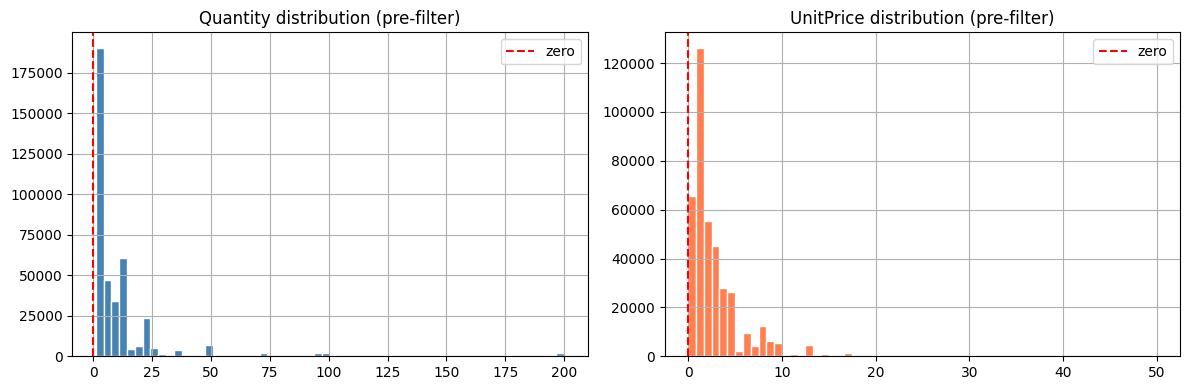


After removing invalid rows: 397884 rows(-40 removed)


In [61]:
print("Quantity<= 0 rows:", (df['Quantity']<=0).sum())
print("UnitPrice<=0 rows:", (df['UnitPrice']<=0).sum())

fig,axes= plt.subplots(1,2,figsize=(12,4))

df['Quantity'].clip(-50,200).hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(0,color='red',linestyle='--', label='zero')
axes[0].set_title('Quantity distribution (pre-filter)')
axes[0].legend()

df['UnitPrice'].clip(0, 50).hist(bins=60, ax=axes[1],
    color='coral', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', label='zero')
axes[1].set_title('UnitPrice distribution (pre-filter)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/before_filter.png',dpi=100,bbox_inches='tight')
plt.show()

#Remove
df=df[df['Quantity']>0]
df=df[df['UnitPrice']>0]
snapshot['after_drop_invalid']=len(df)
print(f"\nAfter removing invalid rows: {len(df)} rows"
      f"(-{snapshot['after_drop_cancelled']-len(df)} removed)")

In [62]:
def iqr_bounds(series, multiplier=3.0):
    Q1=series.quantile(0.25)
    Q3=series.quantile(0.75)
    IQR=Q3-Q1
    lower=Q1 - multiplier*IQR
    upper=Q3 + multiplier*IQR
    return lower,upper

q_lower,q_upper =iqr_bounds(df['Quantity'])
p_lower,p_upper =iqr_bounds(df['UnitPrice'])

print(f"Quantity bounds  : [{q_lower:.1f}, {q_upper:.1f}]")
print(f"UnitPrice bounds : [{p_lower:.2f}, {p_upper:.2f}]")

outlier_mask=(
    (df['Quantity']<q_lower) | (df['Quantity']>q_upper) | (df['UnitPrice']<p_lower) | (df['UnitPrice']>p_upper)
)
print(f"\nOutlier rows flagged: {outlier_mask.sum()}")
print("Sample outliers")
print(df[outlier_mask][['InvoiceNo','Description','Quantity','UnitPrice','CustomerID']].head(10))


Quantity bounds  : [-28.0, 42.0]
UnitPrice bounds : [-6.25, 11.25]

Outlier rows flagged: 28122
Sample outliers
    InvoiceNo                          Description  Quantity  UnitPrice  \
31     536370          INFLATABLE POLITICAL GLOBE         48       0.85   
45     536370                              POSTAGE         3      18.00   
46     536371      PAPER CHAIN KIT 50'S CHRISTMAS         80       2.55   
82     536376    HOT WATER BOTTLE TEA AND SYMPATHY        48       3.45   
83     536376     RED HANGING HEART T-LIGHT HOLDER        64       2.55   
96     536378      PACK OF 72 RETROSPOT CAKE CASES       120       0.42   
101    536378  CHARLIE & LOLA WASTEPAPER BIN FLORA        48       1.25   
102    536378   RED CHARLIE+LOLA PERSONAL DOORSIGN        96       0.38   
147    536382               TOY TIDY PINK POLKADOT        50       1.85   
151    536382      3 TIER CAKE TIN GREEN AND CREAM         2      14.95   

     CustomerID  
31        12583  
45        12583  
46      

After removing outliers: 369762 rows(-28122 removed)


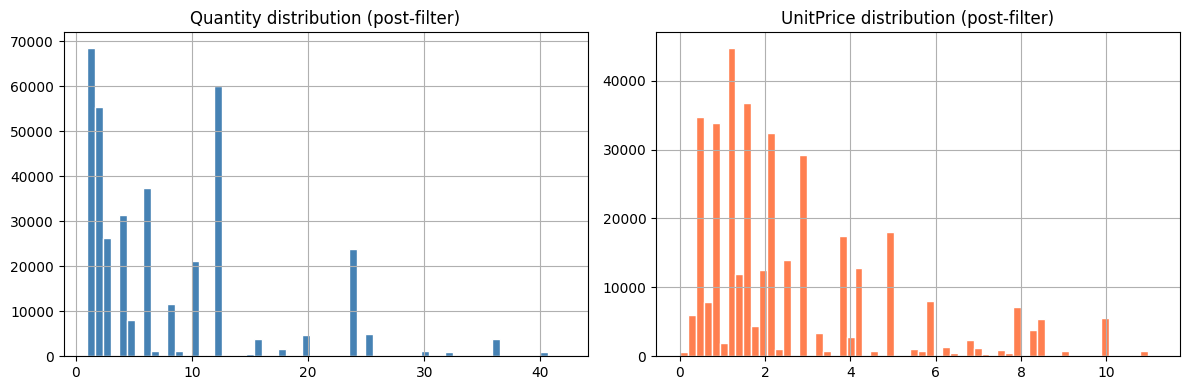

In [63]:
#Drop outliers
df=df[~outlier_mask]
snapshot['after_drop_outliers']=len(df)
print(f"After removing outliers: {len(df)} rows"
      f"(-{snapshot['after_drop_invalid']-len(df)} removed)")

fig, axes=plt.subplots(1,2, figsize=(12,4))

df['Quantity'].hist(bins=60, ax=axes[0], color='steelblue',edgecolor='white')
axes[0].set_title("Quantity distribution (post-filter)")

df['UnitPrice'].hist(bins=60, ax=axes[1], color='coral',edgecolor='white')
axes[1].set_title("UnitPrice distribution (post-filter)")

plt.tight_layout()
plt.savefig('../outputs/after_filter.png',dpi=100,bbox_inches='tight')
plt.show()


In [64]:
print("Data types before fix:")
print(df.dtypes)

df['StockCode']=df['StockCode'].astype(str)
df['Description']=df['Description'].astype(str).str.upper()

df['Revenue']=df['Quantity']*df['UnitPrice']

print("\nData types after fix:")
print(df.dtypes)
print("\nRevenue column added:")
print(df['Revenue'].describe())

Data types before fix:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int32
Country                object
dtype: object

Data types after fix:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int32
Country                object
Revenue               float64
dtype: object

Revenue column added:
count    369762.000000
mean         14.360022
std          17.676065
min           0.001000
25%           4.200000
50%          10.200000
75%          17.700000
max         438.000000
Name: Revenue, dtype: float64


In [65]:
print("Remaining null values:")
print(df.isnull().sum())
print("\nNegative Revenue Rows:", (df['Revenue']<=0).sum())

Remaining null values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

Negative Revenue Rows: 0


In [66]:
snapshot['final']=len(df)

print("="*50)
print("Cleaning Summary")
print("="*50)

steps=[
    ("Raw data",                        'raw'),
    ("After drop null CustomerID",      'after_drop_null_customers'),
    ("After drop null Description",     'after_drop_null_description'),
    ("After remove cancellations",      'after_drop_cancelled'),
    ("After remove invalid Qty/Price",  'after_drop_invalid'),
    ("After remove outliers",           'after_drop_outliers'),
    ("Final clean dataset",             'final'),
]

prev = snapshot['raw']
for label, key in steps:
    val = snapshot[key]
    removed = prev - val if key != 'raw' else 0
    pct = removed / snapshot['raw'] * 100
    marker = f"  (-{removed:,} rows, -{pct:.1f}%)" if removed > 0 else ""
    print(f"{label:<38}: {val:>7,}{marker}")
    prev = val

retention = snapshot['final'] / snapshot['raw'] * 100
print(f"\nData retained: {retention:.1f}%")
print(f"Unique customers in clean data: {df['CustomerID'].nunique():,}")
print(f"Date range: {df['InvoiceDate'].min().date()} to "
      f"{df['InvoiceDate'].max().date()}")



Cleaning Summary
Raw data                              : 541,909
After drop null CustomerID            : 406,829  (-135,080 rows, -24.9%)
After drop null Description           : 406,829
After remove cancellations            : 397,924  (-8,905 rows, -1.6%)
After remove invalid Qty/Price        : 397,884  (-40 rows, -0.0%)
After remove outliers                 : 369,762  (-28,122 rows, -5.2%)
Final clean dataset                   : 369,762

Data retained: 68.2%
Unique customers in clean data: 4,228
Date range: 2010-12-01 to 2011-12-09


In [67]:
df.to_csv('../outputs/clean_data.csv', index=False)
print("Saved to ../outputs/clean_data.csv")
print("Shape:", df.shape)


Saved to ../outputs/clean_data.csv
Shape: (369762, 9)
